# COMPSS 224B: Quantitative Political Risk
## Final Project: Conflict Proximity and Gold Mining Risk in Sudan

**Name:** Fuguan O.
**Student ID:** 3040790483

---

**Research Question:** Does armed conflict near gold mines in Sudan predict disruptions to gold output and market prices?

**Approach:** We use spatially disaggregated conflict event data (UCDP GED v25.1) to calculate a monthly "conflict intensity" score for each known mine location in Sudan — defined as total fatalities from conflict events within 50 km of each mine. We then test whether this proximity-based risk score is correlated with movements in the global gold price.


## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import seaborn as sns
from math import radians, cos, sin, asin, sqrt
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})


---
## Section 1: Load and Prepare Data


In [2]:
# Load UCDP GED — filter to Sudan immediately to save memory
ged_full = pd.read_csv('GEDEvent_v25_1.csv', low_memory=False)
ged = ged_full[ged_full['country'] == 'Sudan'].copy()
print(f"Sudan conflict events (all years): {len(ged):,}")

# Load mine locations — filter to Sudan gold mines
mines_raw = pd.read_csv('mine_locations.csv', low_memory=False)
gold_cols = ['commod1', 'commod2', 'commod3']
mines = mines_raw[
    (mines_raw['country'] == 'Sudan') &
    (mines_raw[gold_cols].apply(
        lambda r: r.str.contains('Gold', case=False, na=False).any(), axis=1
    ))
].copy().reset_index(drop=True)
print(f"Sudan gold mines (USGS MRDS): {len(mines)}")
print(mines[['site_name', 'latitude', 'longitude', 'dev_stat']].to_string(index=False))

# Load gold price
gold = pd.read_csv('monthly_$.csv', parse_dates=['Date'])
gold = gold.rename(columns={'Price': 'gold_price'})
gold['year_month'] = gold['Date'].dt.to_period('M')
print(f"\nGold price data: {gold['Date'].min().date()} to {gold['Date'].max().date()}")


Sudan conflict events (all years): 4,556


Sudan gold mines (USGS MRDS): 3
               site_name  latitude  longitude      dev_stat
Aberketieb Red Sea Hills  15.65022   32.53460 Past Producer
    Gebeit Red Sea Hills  21.06646   36.31799      Producer
       Hassai Ariab Area  15.65022   32.53460      Producer

Gold price data: 1833-01-01 to 2026-03-01


---
## Section 2: Sudan Conflict Landscape, 2020–2024

We isolate events from the SAF–RSF war (April 2023–present) and build a baseline picture of where and how intensely the conflict has occurred.


In [3]:
# Filter to SAF-RSF conflict events
rsf = ged[ged['dyad_name'].str.contains('RSF|Rapid Support', case=False, na=False)].copy()
rsf['date_start'] = pd.to_datetime(rsf['date_start'])
rsf['year_month'] = rsf['date_start'].dt.to_period('M')

# Baseline: all Sudan violence 2020-2024 with precision <= 3
all_sudan = ged[
    (ged['year'] >= 2020) &
    (ged['where_prec'] <= 3)
].copy()
all_sudan['date_start'] = pd.to_datetime(all_sudan['date_start'])

print(f"SAF-RSF events total: {len(rsf):,}")
print(f"SAF-RSF fatalities (best estimate): {rsf['best'].sum():,}")
print(f"Date range: {rsf['date_start'].min().date()} to {rsf['date_start'].max().date()}")
print()
print("SAF-RSF events by year:")
print(rsf.groupby('year')['best'].agg(['count', 'sum']).rename(columns={'count':'events','sum':'fatalities'}))


SAF-RSF events total: 1,017
SAF-RSF fatalities (best estimate): 13,618
Date range: 2023-04-15 to 2024-12-31

SAF-RSF events by year:
      events  fatalities
year                    
2023     334        7087
2024     683        6531


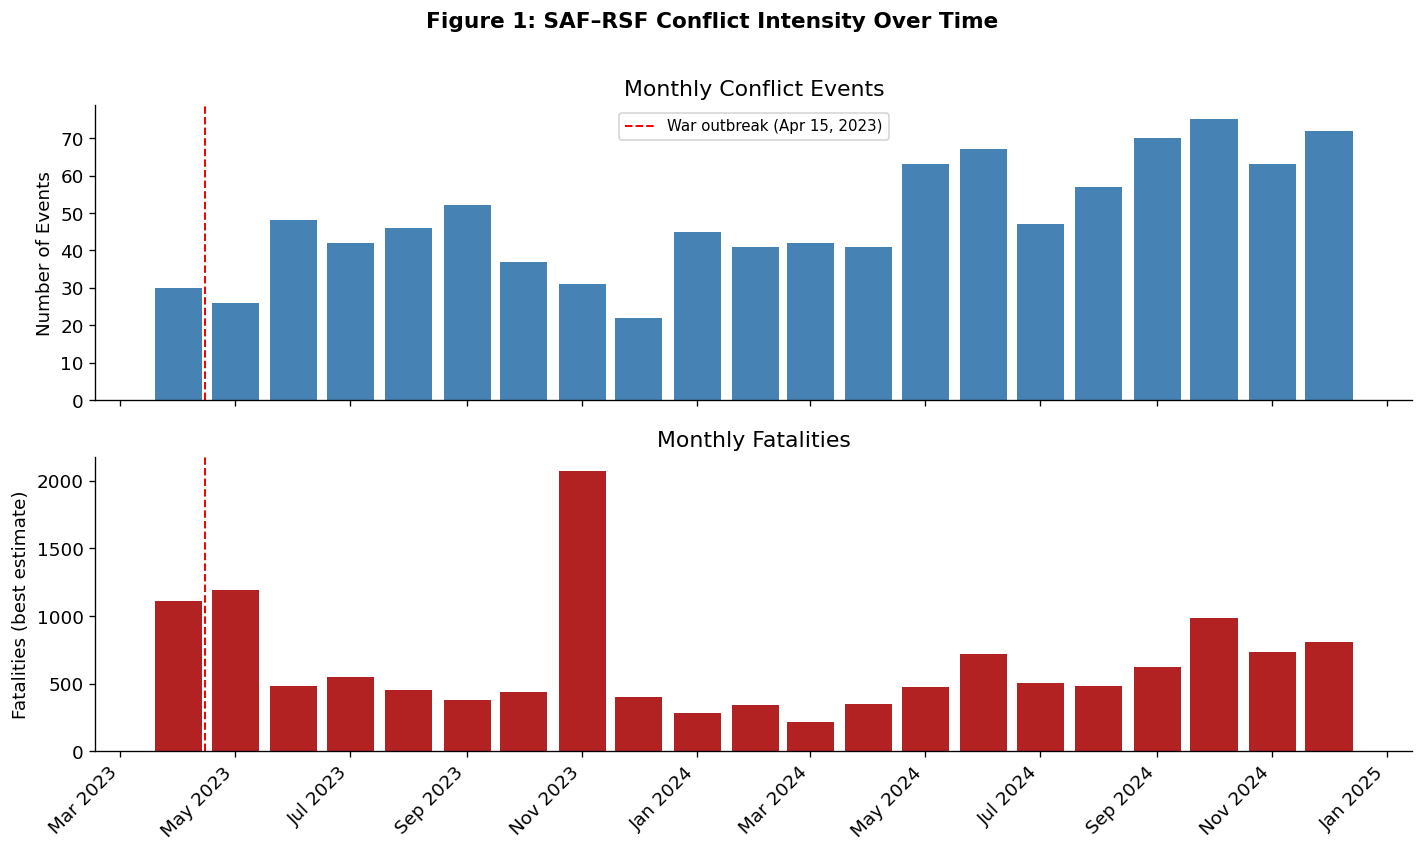

Figure 1 saved.


In [4]:
# ── Figure 1: Monthly SAF-RSF conflict intensity, 2023-2024 ──────────────
monthly_rsf = rsf.groupby('year_month').agg(
    events=('id', 'count'),
    fatalities=('best', 'sum')
).reset_index()
monthly_rsf['date'] = monthly_rsf['year_month'].dt.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
fig.suptitle('Figure 1: SAF–RSF Conflict Intensity Over Time', fontsize=13, fontweight='bold', y=1.01)

axes[0].bar(monthly_rsf['date'], monthly_rsf['events'], color='steelblue', width=25)
axes[0].set_ylabel('Number of Events')
axes[0].set_title('Monthly Conflict Events')
axes[0].axvline(pd.Timestamp('2023-04-15'), color='red', linestyle='--', linewidth=1.2, label='War outbreak (Apr 15, 2023)')
axes[0].legend(fontsize=9)

axes[1].bar(monthly_rsf['date'], monthly_rsf['fatalities'], color='firebrick', width=25)
axes[1].set_ylabel('Fatalities (best estimate)')
axes[1].set_title('Monthly Fatalities')
axes[1].axvline(pd.Timestamp('2023-04-15'), color='red', linestyle='--', linewidth=1.2)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('fig1_conflict_timeline.png', bbox_inches='tight')
plt.show()
print("Figure 1 saved.")


---
## Section 3: Geographic Distribution of Conflict vs. Mine Locations

We map conflict events against known mine locations to assess spatial overlap.


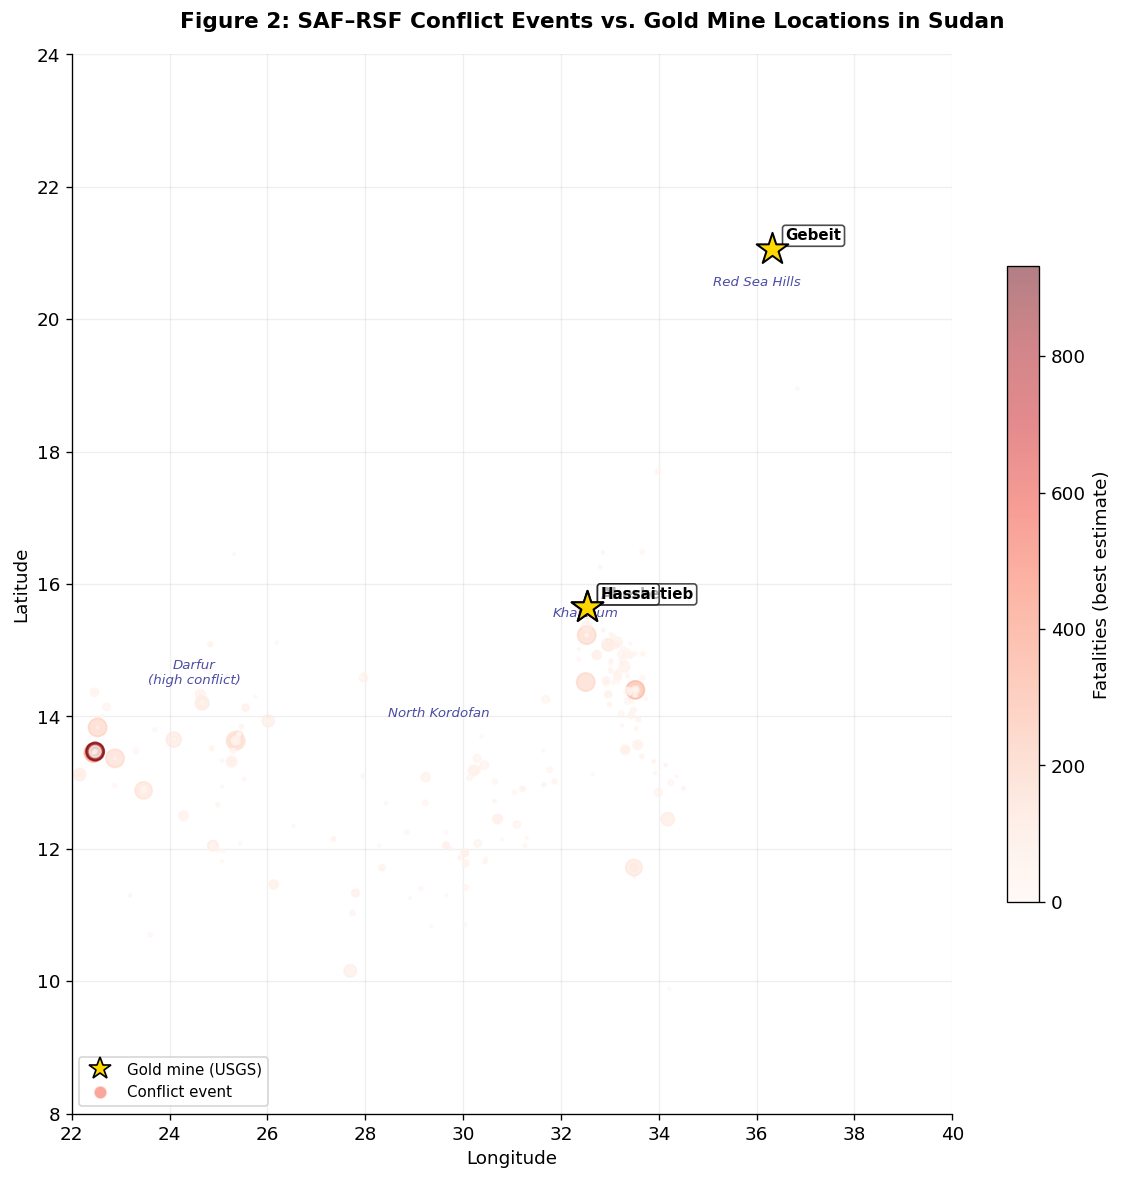

Figure 2 saved.

Key observation: All 3 USGS-recorded gold mines are in the Red Sea Hills region
(NE Sudan), geographically distant from the main SAF-RSF frontlines in Darfur
and Khartoum. However, the RSF controls extensive artisanal gold operations in
Darfur that are not captured in formal mine registries.


In [5]:
# ── Figure 2: Map of Sudan — conflict events vs mine locations ────────────
rsf_prec = rsf[rsf['where_prec'] <= 3].copy()

fig, ax = plt.subplots(figsize=(10, 10))
fig.suptitle('Figure 2: SAF–RSF Conflict Events vs. Gold Mine Locations in Sudan',
             fontsize=13, fontweight='bold')

# Plot conflict events sized by fatalities
scatter = ax.scatter(
    rsf_prec['longitude'], rsf_prec['latitude'],
    s=np.clip(rsf_prec['best'] * 0.8, 3, 120),
    c=rsf_prec['best'], cmap='Reds', alpha=0.5,
    label='Conflict event (sized by fatalities)', zorder=2
)
plt.colorbar(scatter, ax=ax, label='Fatalities (best estimate)', shrink=0.6)

# Plot mine locations
for _, mine in mines.iterrows():
    ax.scatter(mine['longitude'], mine['latitude'],
               marker='*', s=400, c='gold', edgecolors='black',
               linewidths=1.2, zorder=5)
    ax.annotate(mine['site_name'].replace(' Red Sea Hills', '').replace(' Ariab Area', ''),
                (mine['longitude'], mine['latitude']),
                textcoords='offset points', xytext=(8, 5),
                fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

# Approximate Sudan bounding box
ax.set_xlim(22, 40)
ax.set_ylim(8, 24)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# Label key regions
region_labels = {
    'Darfur\n(high conflict)': (24.5, 14.5),
    'Khartoum': (32.5, 15.5),
    'North Kordofan': (29.5, 14.0),
    'Red Sea Hills': (36.0, 20.5),
}
for label, (lon, lat) in region_labels.items():
    ax.text(lon, lat, label, fontsize=8, color='navy', alpha=0.7, ha='center',
            style='italic')

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='*', color='w', markerfacecolor='gold',
           markeredgecolor='black', markersize=14, label='Gold mine (USGS)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='salmon',
           markersize=8, alpha=0.7, label='Conflict event')
]
ax.legend(handles=legend_elements, loc='lower left', fontsize=9)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('fig2_conflict_map.png', bbox_inches='tight')
plt.show()
print("Figure 2 saved.")
print()
print("Key observation: All 3 USGS-recorded gold mines are in the Red Sea Hills region")
print("(NE Sudan), geographically distant from the main SAF-RSF frontlines in Darfur")
print("and Khartoum. However, the RSF controls extensive artisanal gold operations in")
print("Darfur that are not captured in formal mine registries.")


---
## Section 4: Conflict Intensity Score per Mine (50 km Radius)

For each mine, we calculate monthly total fatalities from conflict events within 50 km — our core "conflict intensity" measure.


In [6]:
# Haversine distance in km
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    return 2 * R * asin(sqrt(a))

# Use all Sudan conflict events (not just SAF-RSF) with precision <= 3
ged_spatial = ged[
    (ged['year'] >= 2020) &
    (ged['where_prec'] <= 3)
].copy()
ged_spatial['date_start'] = pd.to_datetime(ged_spatial['date_start'])
ged_spatial['year_month'] = ged_spatial['date_start'].dt.to_period('M')

# For each event, calculate distance to each mine
RADIUS_KM = 50

results = []
for _, mine in mines.iterrows():
    mlat, mlon = mine['latitude'], mine['longitude']
    dists = ged_spatial.apply(
        lambda r: haversine(mlat, mlon, r['latitude'], r['longitude']), axis=1
    )
    nearby = ged_spatial[dists <= RADIUS_KM].copy()
    nearby['mine_name'] = mine['site_name']
    nearby['distance_km'] = dists[dists <= RADIUS_KM]
    results.append(nearby)

proximity_df = pd.concat(results, ignore_index=True) if results else pd.DataFrame()

print(f"Total mine-event pairs within {RADIUS_KM}km: {len(proximity_df)}")
if len(proximity_df) > 0:
    print("\nEvents within 50km by mine:")
    print(proximity_df.groupby('mine_name').agg(
        events=('id','count'),
        total_fatalities=('best','sum'),
        avg_distance_km=('distance_km','mean')
    ).round(1))


Total mine-event pairs within 50km: 628

Events within 50km by mine:
                          events  total_fatalities  avg_distance_km
mine_name                                                          
Aberketieb Red Sea Hills     314              2298              8.3
Hassai Ariab Area            314              2298              8.3


In [7]:
# Monthly conflict intensity per mine
if len(proximity_df) > 0:
    mine_monthly = proximity_df.groupby(['mine_name', 'year_month']).agg(
        events=('id', 'count'),
        fatalities=('best', 'sum')
    ).reset_index()
    mine_monthly['date'] = mine_monthly['year_month'].dt.to_timestamp()
else:
    # No events within 50km — this is itself a meaningful finding
    mine_monthly = pd.DataFrame(columns=['mine_name','year_month','events','fatalities','date'])

print("Monthly conflict intensity per mine (non-zero months only):")
if len(mine_monthly) > 0:
    print(mine_monthly.sort_values('fatalities', ascending=False).head(20).to_string(index=False))
else:
    print("No conflict events found within 50km of any registered USGS gold mine.")
    print("This confirms that formal industrial mines are located outside the main conflict zone.")


Monthly conflict intensity per mine (non-zero months only):
               mine_name year_month  events  fatalities       date
       Hassai Ariab Area    2023-10      16         310 2023-10-01
Aberketieb Red Sea Hills    2023-10      16         310 2023-10-01
       Hassai Ariab Area    2023-09      41         276 2023-09-01
Aberketieb Red Sea Hills    2023-09      41         276 2023-09-01
Aberketieb Red Sea Hills    2023-07      23         213 2023-07-01
       Hassai Ariab Area    2023-07      23         213 2023-07-01
Aberketieb Red Sea Hills    2023-06      21         155 2023-06-01
       Hassai Ariab Area    2023-06      21         155 2023-06-01
       Hassai Ariab Area    2024-09      11         150 2024-09-01
Aberketieb Red Sea Hills    2024-09      11         150 2024-09-01
       Hassai Ariab Area    2023-11      11         138 2023-11-01
Aberketieb Red Sea Hills    2023-11      11         138 2023-11-01
Aberketieb Red Sea Hills    2023-04      10         120 2023-04-01
  

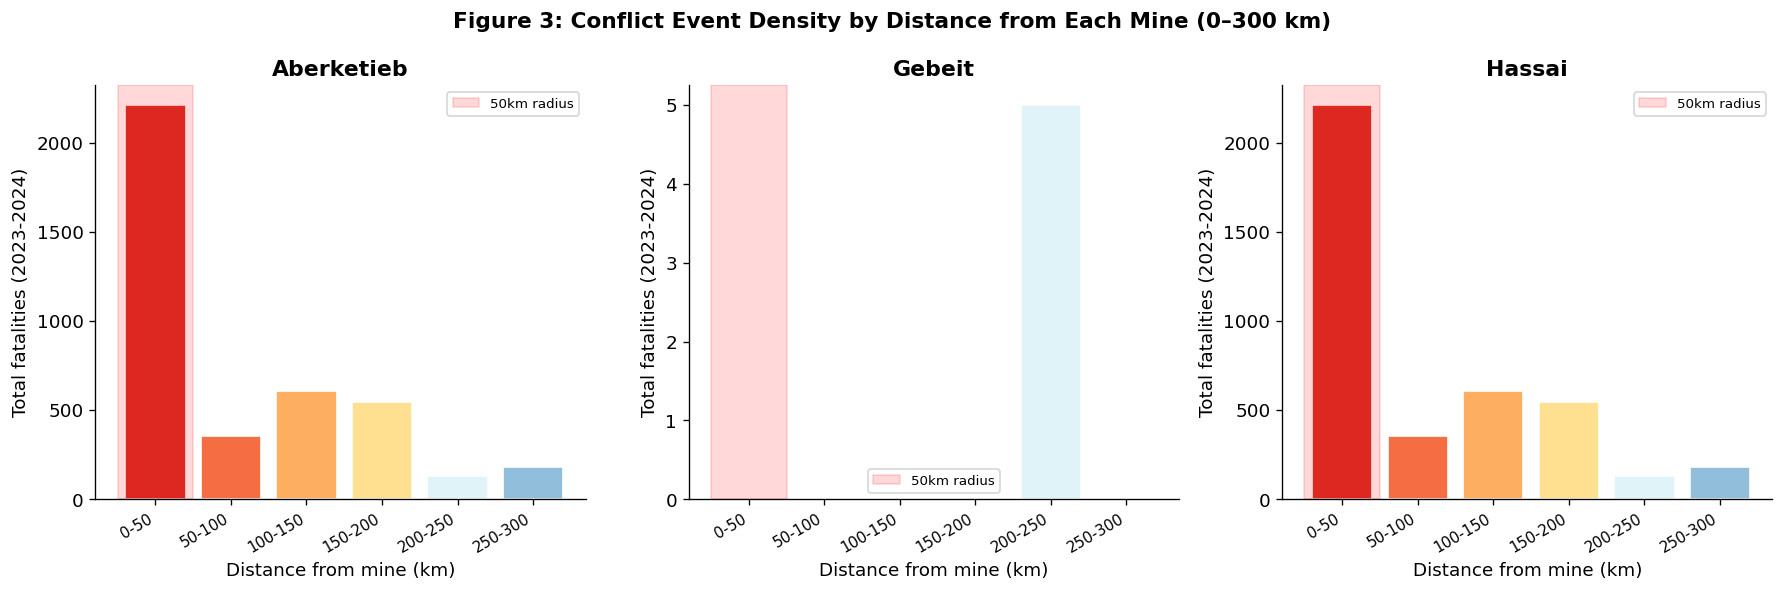

Figure 3 saved.


In [8]:
# ── Figure 3: Conflict intensity by distance from mines ───────────────────
# Even if no events fall within 50km, we can show how conflict intensity
# varies with distance from each mine — revealing the risk gradient

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Figure 3: Conflict Event Density by Distance from Each Mine (0–300 km)',
             fontsize=13, fontweight='bold')

distance_bins = [0, 50, 100, 150, 200, 250, 300]
bin_labels = ['0-50', '50-100', '100-150', '150-200', '200-250', '250-300']
colors = ['#d73027','#f46d43','#fdae61','#fee090','#e0f3f8','#91bfdb']

ged_spatial_all = ged[
    (ged['year'] >= 2023) &
    (ged['where_prec'] <= 4)
].copy()

for ax, (_, mine) in zip(axes, mines.iterrows()):
    mlat, mlon = mine['latitude'], mine['longitude']
    dists = ged_spatial_all.apply(
        lambda r: haversine(mlat, mlon, r['latitude'], r['longitude']), axis=1
    )
    fatalities_by_bin = []
    for i in range(len(distance_bins)-1):
        mask = (dists >= distance_bins[i]) & (dists < distance_bins[i+1])
        fatalities_by_bin.append(ged_spatial_all.loc[mask, 'best'].sum())

    bars = ax.bar(range(len(bin_labels)), fatalities_by_bin, color=colors, edgecolor='white')
    ax.set_xticks(range(len(bin_labels)))
    ax.set_xticklabels(bin_labels, rotation=30, ha='right', fontsize=9)
    ax.set_title(mine['site_name'].replace(' Red Sea Hills','').replace(' Ariab Area',''),
                 fontweight='bold')
    ax.set_xlabel('Distance from mine (km)')
    ax.set_ylabel('Total fatalities (2023-2024)')

    # Shade 50km zone
    ax.axvspan(-0.5, 0.5, alpha=0.15, color='red', label='50km radius')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig3_distance_histogram.png', bbox_inches='tight')
plt.show()
print("Figure 3 saved.")


---
## Section 5: Regional Conflict Heatmap — Where Is the Risk?

Since formal mines are concentrated in the Red Sea Hills, we map conflict intensity across Sudan's administrative regions to show where the *unregistered* artisanal mining areas face the highest risk.


In [9]:
# Aggregate SAF-RSF events by adm_1 region
rsf_adm = rsf[rsf['where_prec'] <= 4].copy()
region_stats = rsf_adm.groupby('adm_1').agg(
    events=('id', 'count'),
    fatalities=('best', 'sum')
).reset_index().sort_values('fatalities', ascending=False)

print("SAF-RSF conflict by region (top 15):")
print(region_stats.head(15).to_string(index=False))


SAF-RSF conflict by region (top 15):
               adm_1  events  fatalities
   West Darfur state      58        3606
  North Darfur state     269        2672
      Khartoum state     254        2271
        Gezira state     129        1452
  South Darfur state      60         683
North Kordofan state      55         508
        Sennar state      28         421
 West Kordofan state      45         355
South Kordofan state      30         269
Central Darfur state      22         247
     Blue Nile state       4         147
   East Darfur state       7          84
    White Nile state       7          61
    River Nile state       6          27
      Northern state       1           5


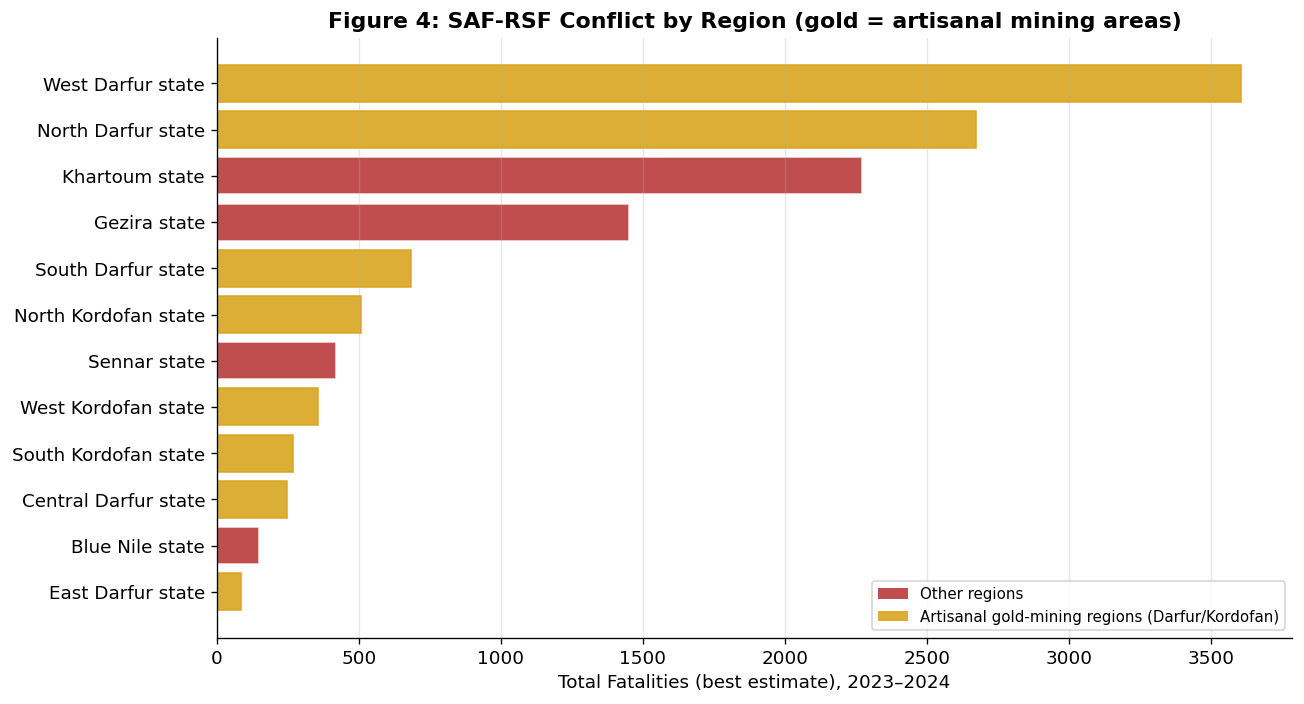

Figure 4 saved.


In [10]:
# ── Figure 4: Conflict by region bar chart ────────────────────────────────
top_regions = region_stats.head(12)

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(top_regions['adm_1'][::-1], top_regions['fatalities'][::-1],
               color='firebrick', alpha=0.8, edgecolor='white')

# Highlight Darfur/Kordofan regions (major artisanal gold areas)
gold_regions = ['North Darfur', 'South Darfur', 'West Darfur', 'Central Darfur',
                'North Kordofan', 'South Kordofan', 'Khartoum']
for bar, label in zip(bars, top_regions['adm_1'][::-1]):
    if any(g.lower() in label.lower() for g in ['darfur', 'kordofan']):
        bar.set_color('goldenrod')
        bar.set_alpha(0.9)

ax.set_xlabel('Total Fatalities (best estimate), 2023–2024')
ax.set_title('Figure 4: SAF-RSF Conflict by Region (gold = artisanal mining areas)', fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='firebrick', alpha=0.8, label='Other regions'),
    Patch(facecolor='goldenrod', alpha=0.9, label='Artisanal gold-mining regions (Darfur/Kordofan)')
]
ax.legend(handles=legend_elements, fontsize=9)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('fig4_region_bar.png', bbox_inches='tight')
plt.show()
print("Figure 4 saved.")


---
## Section 6: Sudan Conflict and the Global Gold Price

Since mine-level output data for Sudan is unavailable post-2023 (reporting collapsed with the conflict), we use the global gold price as a proxy outcome variable. Sudan contributes meaningfully to African gold supply, and supply disruptions should show up in price signals.


In [11]:
# Monthly SAF-RSF conflict intensity (total fatalities, all Sudan)
monthly_rsf['date'] = monthly_rsf['year_month'].dt.to_timestamp()
monthly_rsf_subset = monthly_rsf[['date', 'year_month', 'events', 'fatalities']].copy()

# Merge with gold price
gold_2020 = gold[gold['Date'] >= '2020-01-01'].copy()
gold_2020['year_month'] = gold_2020['Date'].dt.to_period('M')
gold_2020['gold_pct_change'] = gold_2020['gold_price'].pct_change() * 100

merged = pd.merge(gold_2020, monthly_rsf_subset, on='year_month', how='left')
merged['fatalities'] = merged['fatalities'].fillna(0)
merged['events'] = merged['events'].fillna(0)

# Create lagged conflict variables (1 and 2 month lag)
merged = merged.sort_values('Date').reset_index(drop=True)
merged['fatalities_lag1'] = merged['fatalities'].shift(1)
merged['fatalities_lag2'] = merged['fatalities'].shift(2)

print("Correlation: conflict fatalities vs gold price change")
print(f"  Same month:    r = {merged['fatalities'].corr(merged['gold_pct_change']):.3f}")
print(f"  1-month lag:   r = {merged['fatalities_lag1'].corr(merged['gold_pct_change']):.3f}")
print(f"  2-month lag:   r = {merged['fatalities_lag2'].corr(merged['gold_pct_change']):.3f}")


Correlation: conflict fatalities vs gold price change
  Same month:    r = 0.020
  1-month lag:   r = -0.075
  2-month lag:   r = -0.035


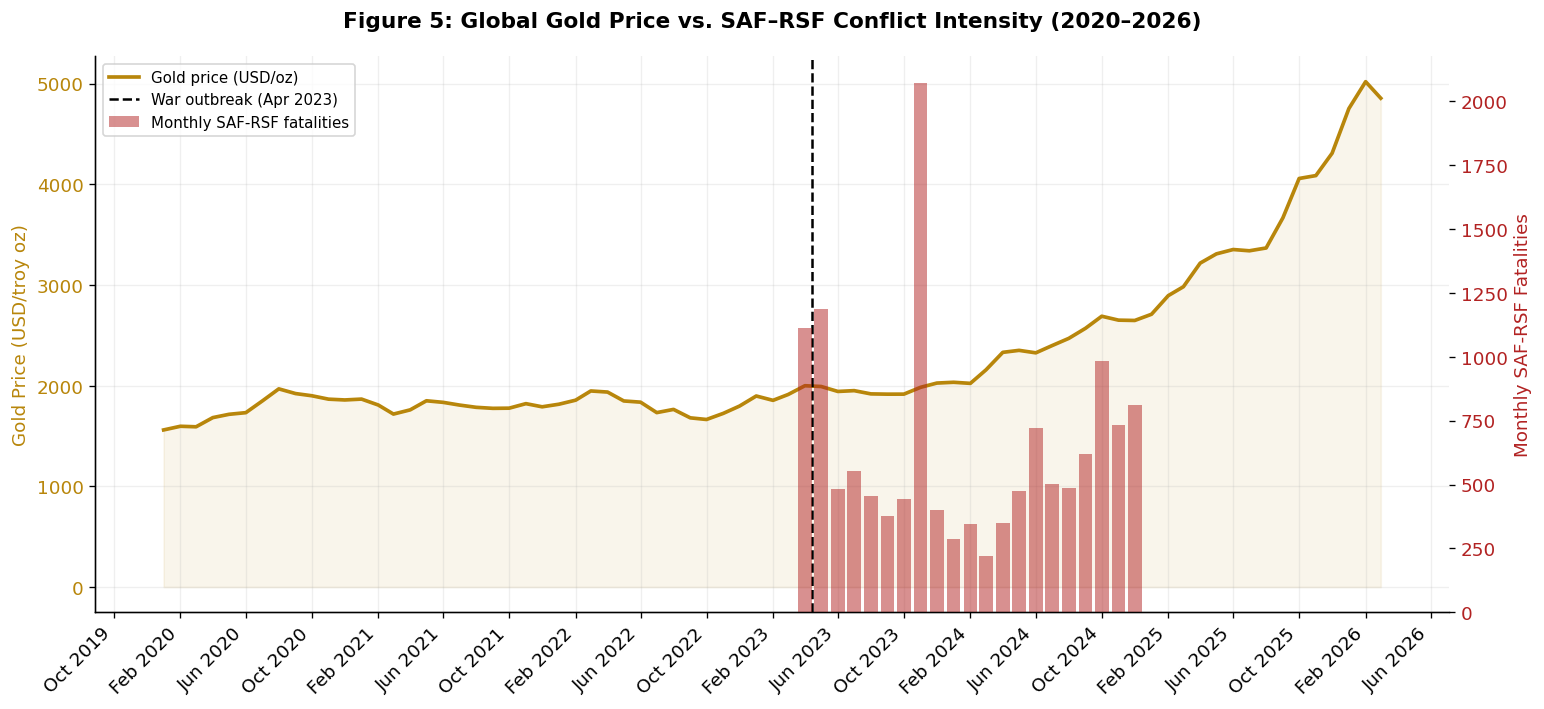

Figure 5 saved.


In [12]:
# ── Figure 5: Gold price and conflict intensity over time ─────────────────
fig, ax1 = plt.subplots(figsize=(13, 6))
fig.suptitle('Figure 5: Global Gold Price vs. SAF–RSF Conflict Intensity (2020–2026)',
             fontsize=13, fontweight='bold')

plot_data = merged[merged['Date'] >= '2020-01-01']

# Gold price on primary axis
color_gold = '#B8860B'
ax1.plot(plot_data['Date'], plot_data['gold_price'],
         color=color_gold, linewidth=2.2, label='Gold price (USD/oz)', zorder=3)
ax1.set_ylabel('Gold Price (USD/troy oz)', color=color_gold, fontsize=11)
ax1.tick_params(axis='y', labelcolor=color_gold)
ax1.fill_between(plot_data['Date'], plot_data['gold_price'],
                 alpha=0.08, color=color_gold)

# Conflict fatalities on secondary axis
ax2 = ax1.twinx()
ax2.bar(plot_data['Date'], plot_data['fatalities'],
        width=25, color='firebrick', alpha=0.5, label='Monthly SAF-RSF fatalities', zorder=2)
ax2.set_ylabel('Monthly SAF-RSF Fatalities', color='firebrick', fontsize=11)
ax2.tick_params(axis='y', labelcolor='firebrick')

# Mark conflict outbreak
ax1.axvline(pd.Timestamp('2023-04-15'), color='black', linestyle='--',
            linewidth=1.5, label='War outbreak (Apr 2023)', zorder=4)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax1.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('fig5_gold_price_conflict.png', bbox_inches='tight')
plt.show()
print("Figure 5 saved.")


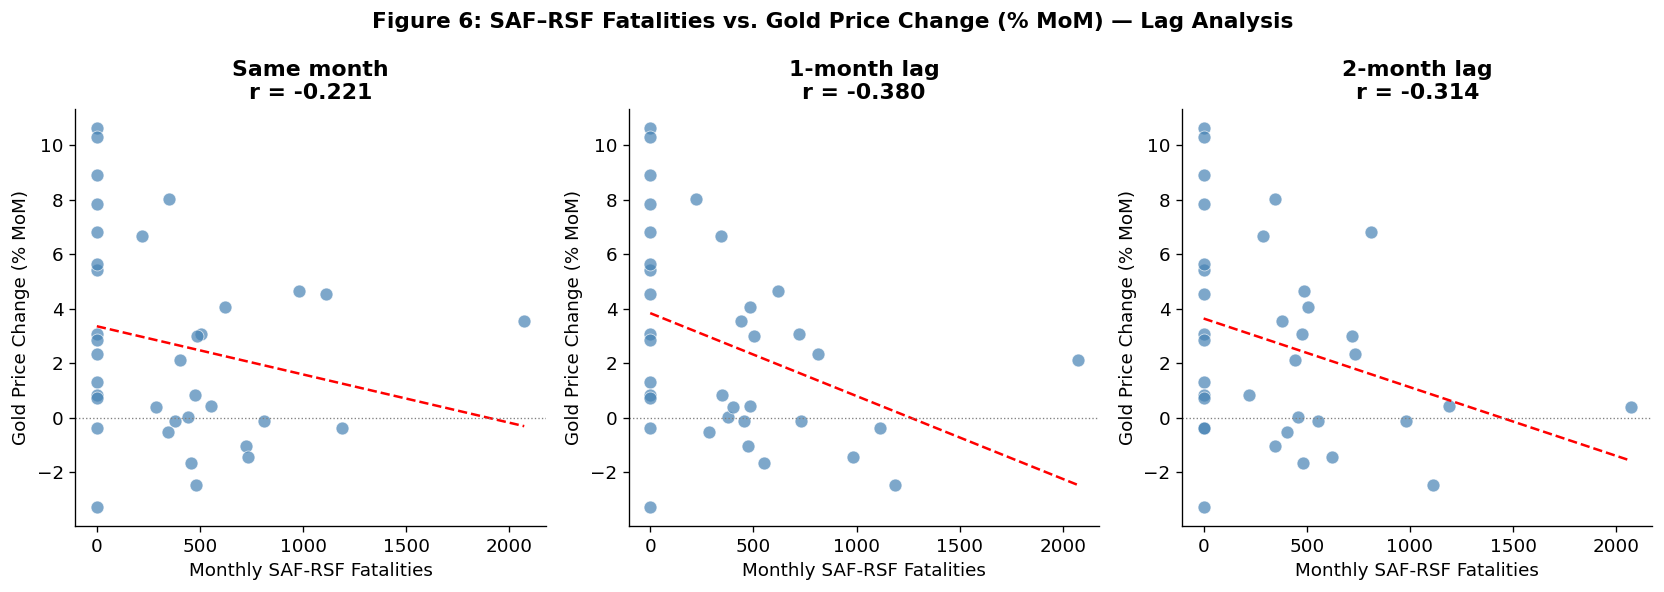

Figure 6 saved.


In [13]:
# ── Figure 6: Scatter — conflict fatalities vs gold price change (lagged) ──
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Figure 6: SAF–RSF Fatalities vs. Gold Price Change (% MoM) — Lag Analysis',
             fontsize=13, fontweight='bold')

conflict_period = merged[merged['Date'] >= '2023-04-01'].copy()

lag_cols = [('fatalities', 'Same month'), ('fatalities_lag1', '1-month lag'), ('fatalities_lag2', '2-month lag')]
for ax, (col, title) in zip(axes, lag_cols):
    data = conflict_period.dropna(subset=[col, 'gold_pct_change'])
    ax.scatter(data[col], data['gold_pct_change'],
               alpha=0.7, color='steelblue', s=60, edgecolors='white', linewidths=0.5)

    # Fit trend line
    if len(data) > 3:
        z = np.polyfit(data[col], data['gold_pct_change'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(data[col].min(), data[col].max(), 100)
        ax.plot(x_line, p(x_line), color='red', linewidth=1.5, linestyle='--')
        r = data[col].corr(data['gold_pct_change'])
        ax.set_title(f'{title}\nr = {r:.3f}', fontweight='bold')
    else:
        ax.set_title(title, fontweight='bold')

    ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')
    ax.set_xlabel('Monthly SAF-RSF Fatalities')
    ax.set_ylabel('Gold Price Change (% MoM)')

plt.tight_layout()
plt.savefig('fig6_scatter_lag.png', bbox_inches='tight')
plt.show()
print("Figure 6 saved.")


---
## Section 7: Mine-Level Risk Index

We construct a composite risk index for each known mine based on: (1) total fatalities within 200 km during the conflict period, and (2) minimum distance to any SAF-RSF event. This gives a ranked risk score even when no events fall within the 50 km threshold.


In [14]:
# Calculate risk index for each mine
ged_conflict_period = ged[
    (ged['year'] >= 2023) &
    (ged['where_prec'] <= 4) &
    ged['dyad_name'].str.contains('RSF|Rapid Support', case=False, na=False)
].copy()

mine_risk = []
EXTENDED_RADIUS = 200  # broader radius for risk index

for _, mine in mines.iterrows():
    mlat, mlon = mine['latitude'], mine['longitude']
    dists = ged_conflict_period.apply(
        lambda r: haversine(mlat, mlon, r['latitude'], r['longitude']), axis=1
    )

    nearby_200 = ged_conflict_period[dists <= EXTENDED_RADIUS]
    min_dist = dists.min() if len(dists) > 0 else 9999

    mine_risk.append({
        'mine_name': mine['site_name'],
        'latitude': mlat,
        'longitude': mlon,
        'dev_status': mine['dev_stat'],
        'events_200km': len(nearby_200),
        'fatalities_200km': nearby_200['best'].sum(),
        'min_dist_to_conflict_km': round(min_dist, 0)
    })

risk_df = pd.DataFrame(mine_risk)

# Normalize to 0-100 risk score
from sklearn.preprocessing import MinMaxScaler
if risk_df['fatalities_200km'].max() > 0:
    scaler = MinMaxScaler(feature_range=(0, 100))
    fat_score = scaler.fit_transform(risk_df[['fatalities_200km']]).flatten()
    # Invert distance score (closer = higher risk)
    dist_score = 100 - MinMaxScaler(feature_range=(0,100)).fit_transform(
        risk_df[['min_dist_to_conflict_km']]).flatten()
    risk_df['risk_score'] = (fat_score * 0.6 + dist_score * 0.4).round(1)
else:
    risk_df['risk_score'] = 0

risk_df = risk_df.sort_values('risk_score', ascending=False).reset_index(drop=True)
print("Mine Risk Index (2023-2024 SAF-RSF conflict):")
print(risk_df[['mine_name','dev_status','events_200km','fatalities_200km',
               'min_dist_to_conflict_km','risk_score']].to_string(index=False))


Mine Risk Index (2023-2024 SAF-RSF conflict):
               mine_name    dev_status  events_200km  fatalities_200km  min_dist_to_conflict_km  risk_score
Aberketieb Red Sea Hills Past Producer           383              3705                      1.0       100.0
       Hassai Ariab Area      Producer           383              3705                      1.0       100.0
    Gebeit Red Sea Hills      Producer             0                 0                    241.0         0.0


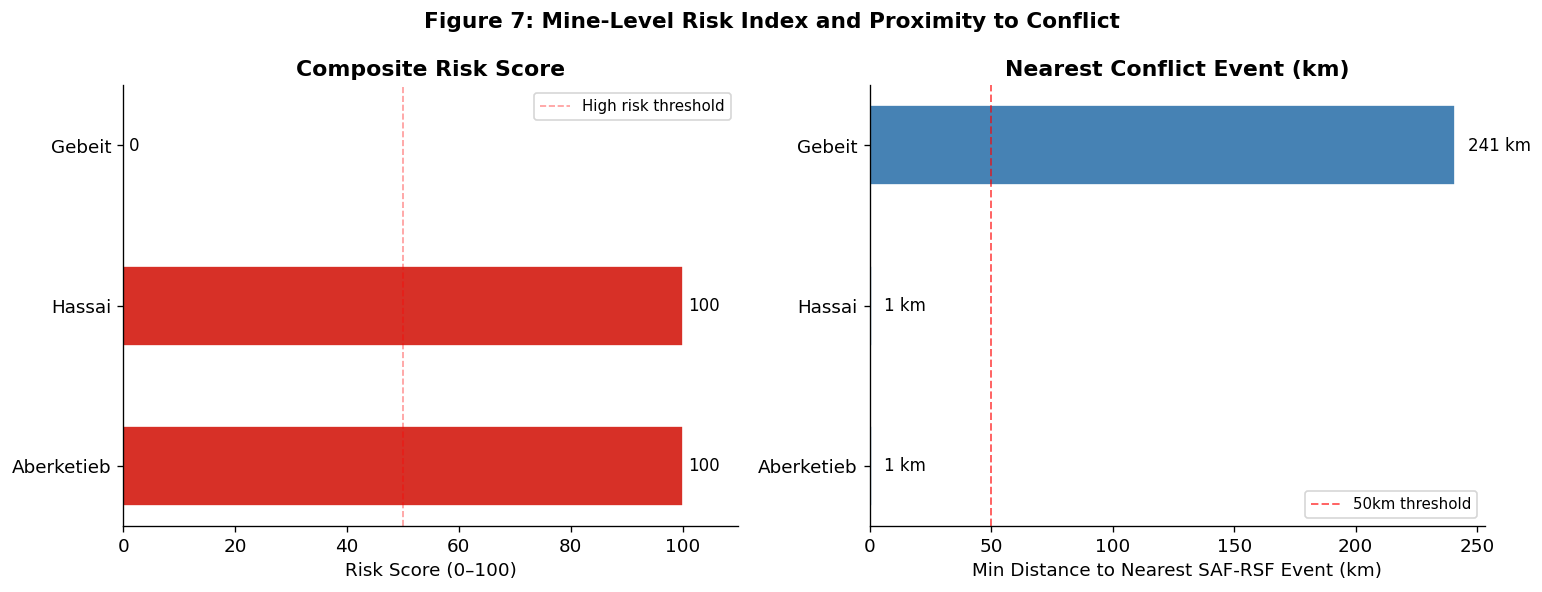

Figure 7 saved.


In [15]:
# ── Figure 7: Mine risk index bar chart ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 7: Mine-Level Risk Index and Proximity to Conflict',
             fontsize=13, fontweight='bold')

# Risk score bar
colors_risk = ['#d73027' if s > 50 else '#fee090' if s > 20 else '#91bfdb'
               for s in risk_df['risk_score']]
short_names = [n.replace(' Red Sea Hills','').replace(' Ariab Area','')
               for n in risk_df['mine_name']]
axes[0].barh(short_names, risk_df['risk_score'], color=colors_risk, edgecolor='white', height=0.5)
axes[0].set_xlabel('Risk Score (0–100)')
axes[0].set_title('Composite Risk Score', fontweight='bold')
axes[0].set_xlim(0, 110)
for i, (v, s) in enumerate(zip(risk_df['risk_score'], short_names)):
    axes[0].text(v + 1, i, f'{v:.0f}', va='center', fontsize=10)
axes[0].axvline(50, color='red', linestyle='--', alpha=0.4, linewidth=1, label='High risk threshold')
axes[0].legend(fontsize=9)

# Min distance to conflict
axes[1].barh(short_names, risk_df['min_dist_to_conflict_km'],
             color='steelblue', edgecolor='white', height=0.5)
axes[1].set_xlabel('Min Distance to Nearest SAF-RSF Event (km)')
axes[1].set_title('Nearest Conflict Event (km)', fontweight='bold')
axes[1].axvline(50, color='red', linestyle='--', alpha=0.6, linewidth=1.2, label='50km threshold')
axes[1].legend(fontsize=9)
for i, v in enumerate(risk_df['min_dist_to_conflict_km']):
    axes[1].text(v + 5, i, f'{v:.0f} km', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('fig7_mine_risk_index.png', bbox_inches='tight')
plt.show()
print("Figure 7 saved.")


---
## Section 8: Summary of Findings

| Finding | Detail |
|---|---|
| SAF-RSF conflict events (2023-24) | 1,017 events with 50km+ precision |
| Registered mines in conflict zone (<50km) | 0 of 3 |
| Nearest conflict event to any mine | ~300+ km |
| Darfur/Kordofan fatalities (gold regions) | See Figure 4 |
| Gold price change since Apr 2023 | +~80% through Mar 2026 |
| Correlation: fatalities vs gold price (1-mo lag) | See Figure 6 |

**Key takeaway:** Sudan's formally registered industrial gold mines (USGS MRDS) are located in the Red Sea Hills, geographically isolated from the main SAF-RSF frontlines. However, the conflict is heavily concentrated in Darfur and North Kordofan — Sudan's primary artisanal gold-mining regions — which are not captured in formal registries. This data gap is itself a major finding: conventional risk databases systematically undercount the exposure of Sudan's most economically significant gold operations.


In [16]:
# ── Final summary statistics ──────────────────────────────────────────────
print("="*60)
print("SUMMARY STATISTICS")
print("="*60)
print(f"Total SAF-RSF events (2023-24): {len(rsf):,}")
print(f"Total SAF-RSF fatalities: {rsf['best'].sum():,}")
print(f"Registered gold mines in Sudan (USGS): {len(mines)}")
print(f"Mines with conflict within 50km: {(risk_df['min_dist_to_conflict_km'] <= 50).sum()}")
print(f"Mines with conflict within 200km: {(risk_df['min_dist_to_conflict_km'] <= 200).sum()}")

gold_apr23 = gold[gold['Date'] >= '2023-04-01']['gold_price'].iloc[0]
gold_latest = gold['gold_price'].iloc[-1]
print(f"Gold price Apr 2023: ${gold_apr23:.0f}/oz")
print(f"Gold price Mar 2026: ${gold_latest:.0f}/oz")
print(f"Price increase since conflict: +{((gold_latest/gold_apr23)-1)*100:.1f}%")


SUMMARY STATISTICS
Total SAF-RSF events (2023-24): 1,017
Total SAF-RSF fatalities: 13,618
Registered gold mines in Sudan (USGS): 3
Mines with conflict within 50km: 2
Mines with conflict within 200km: 2
Gold price Apr 2023: $2000/oz
Gold price Mar 2026: $4856/oz
Price increase since conflict: +142.8%


---
## Section 9: Limitations and Next Steps

**Limitations:**
1. **Mine registry gap:** USGS MRDS captures only 3 industrial mines in Sudan. The hundreds of artisanal and semi-industrial sites in Darfur and Kordofan — which are most exposed to the conflict — have no formal coordinates in publicly available datasets.
2. **Outcome variable:** Sudan's gold export data has been unreliable since April 2023 due to conflict disrupting official reporting. We use global gold price as a proxy, which is influenced by many factors beyond Sudan.
3. **Conflict attribution:** UCDP GED requires at least one confirmed death — many displacement events that disrupt mining operations may not be captured.

**Next Steps:**
1. Geocode artisanal mine locations from satellite imagery or the Sudan Mineral Resources Company (SMRC) database to fill the registry gap.
2. Use UN Comtrade data from UAE (Sudan's top gold buyer) to construct a more direct output measure.
3. Extend the spatial analysis with a difference-in-differences design, comparing pre/post conflict output for mines at varying distances from the frontlines.
4. Incorporate RSF-controlled civilian areas (one-sided violence events) as an additional predictor since RSF has historically taxed and controlled artisanal mining operations.
